In [1]:
import os
import shap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

c:\Users\301-2\anaconda3\envs\ct_study\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
# Setup paths
RESULTS_DIR = "../results/shap_outputs"

# === 2. Load model and dataset ===
logreg = joblib.load("../models/logreg_pipeline.pkl")
df_final_onehot = pd.read_csv("../../data/final/df_final_onehot.csv")

target = ['overall_status']
num_features = ['number_of_arms', 'log_enrollment', 'log_duration', 'intervention_count']
flag_features = ['has_dmc','has_expanded_access', 'is_fda_regulated_drug','is_fda_regulated_device', 'has_multiple_intervention_types', 'healthy_volunteers']
extra_feature = ['high_enroll_flag_975']
core_features = df_final_onehot.drop(columns = num_features + extra_feature + flag_features + target)
core_cols = [c for c in core_features if c not in ('nct_id')]

X = df_final_onehot[num_features + core_cols + flag_features + extra_feature]
y = df_final_onehot['overall_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)


In [9]:
# === 3. Build SHAP Explainer (Linear) ===
model_inner = logreg.named_steps['clf'] if hasattr(logreg, 'named_steps') else logreg
explainer_log = shap.LinearExplainer(model_inner, X_train)
shap_values_log = explainer_log(X_test)

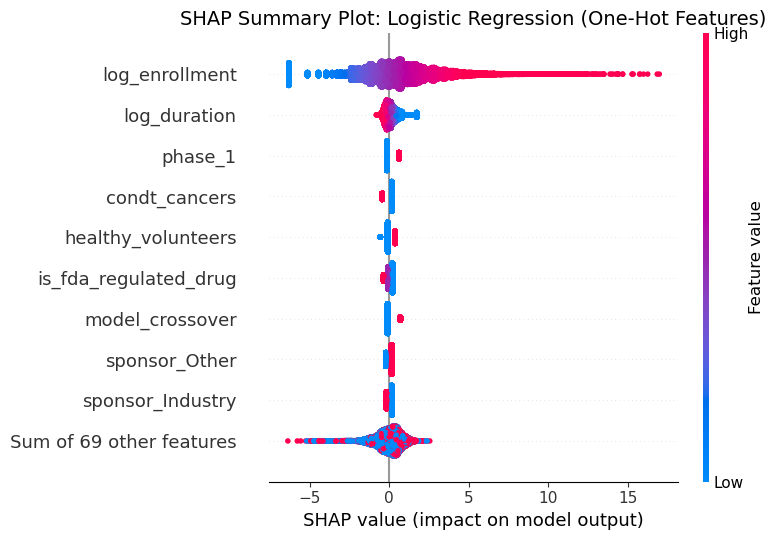

In [10]:
# 6. Summary Plot 출력 및 저장
plt.figure(figsize=(12, 8))
shap.plots.beeswarm(shap_values_log, show=False)
plt.title("SHAP Summary Plot: Logistic Regression (One-Hot Features)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "shap_summary_logreg.png"), dpi=300, bbox_inches="tight")
plt.show()